In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils import logger
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

os.chdir(config.paths.roots.project)

torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam0 : 146
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam1 : 146
INFO     | setup | Train Dataset       : 292 samples
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam0 : 146
INFO     | _get_names | Image Pair Counts : MOO09_short_1_updown cam1 : 146
INFO     | setup | Validation Dataset  : 292 samples


In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

torch.Size([139, 3, 32, 32]) torch.Size([139, 3, 32, 32])
torch.Size([139, 2]) torch.Size([139, 2])


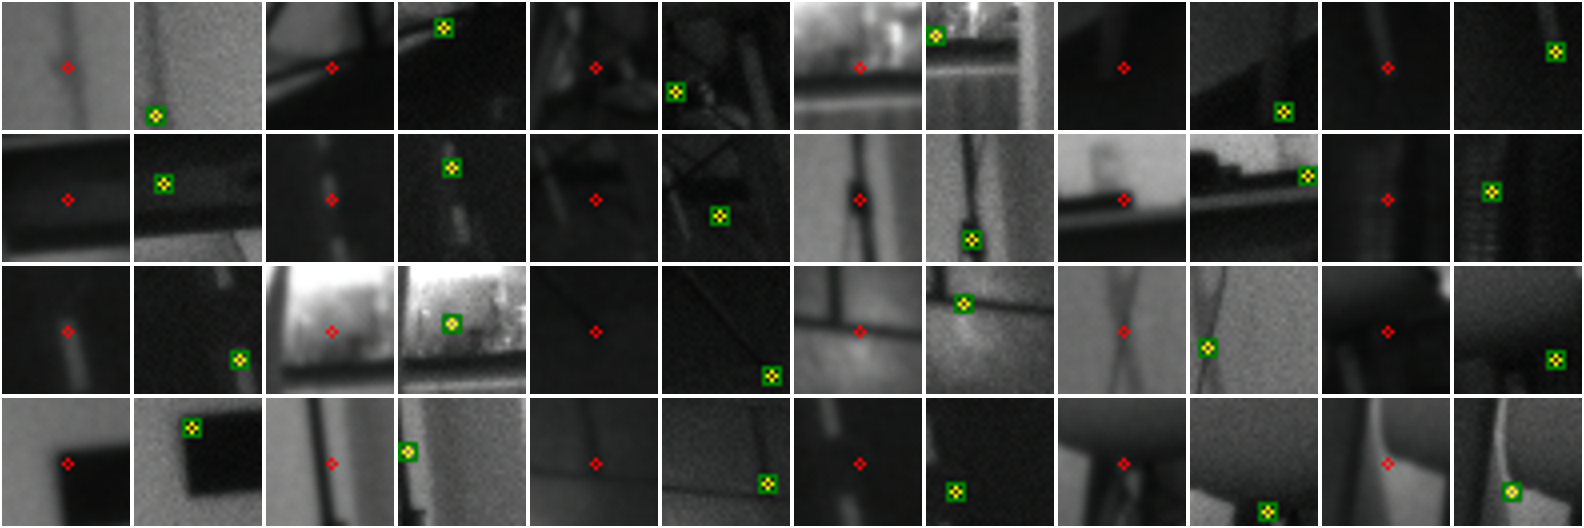

In [7]:
from utils import show_batch

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    limit_count=24, 
    n_columns=6,
)

In [8]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


In [9]:
dm.teardown()

# Check Model

In [19]:
from src import MatcherModel
model = MatcherModel()

In [12]:
from utils import count_params
count_params(model.model)

416258

In [20]:
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

target_coords_pred = model(reference_patches, target_patches, patch_level_reference_coords)

print(f'target_coords_pred shape : {target_coords_pred.shape}')

reference_patches shape : torch.Size([163, 3, 32, 32])
target_patches shape : torch.Size([163, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([163, 2])


x.shape torch.Size([163, 128, 32, 32])
self.positional_encoding.shape torch.Size([1, 128, 32, 32])
target_coords_pred shape : torch.Size([163, 2])
